#SVM & Naive bayes#

###Theory###

1. What is a Support Vector Machine (SVM)?
Answer : 
A Support Vector Machine (SVM) is a supervised learning algorithm for classification (and regression) that finds the best separating boundary — the maximum-margin hyperplane — between classes. Think of SVM as drawing the widest possible road between two groups of points so new points fall clearly on one side or the other. Mathematically it optimizes a convex objective to maximize margin while controlling misclassification.
Example: For a 2D dataset of red and blue points, SVM finds a line that maximizes the distance to the nearest red and blue points; those nearest points are the support vectors that define the line.
(imagine stretching a rubber band around each class and placing a ruler between them — SVM finds that ruler.)

2. What is the difference between Hard Margin and Soft Margin SVM?
Answer : 
Hard Margin SVM requires perfect separation. it finds a hyperplane that classifies all training points correctly and maximizes margin. This only works when data are linearly separable and noise-free. Soft Margin SVM relaxes that requirement by allowing some misclassifications via slack variables and a penalty parameter . Soft margin trades off margin width against classification errors, making SVM robust to noise and overlapping classes.
Example: If two classes slightly overlap due to measurement noise, a hard-margin SVM fails (no feasible solution), while a soft-margin SVM tolerates a few misclassified points to produce a stable boundary.
(So in avove eamle we can say thathard margin is strict and brittle; soft margin is forgiving and practical.)

3. What is the mathematical intuition behind SVM?
Answer : 
SVM frames classification as a constrained optimization: maximize the margin  subject to class constraints  with slack . The primal objective minimizes . The margin maximization yields better generalization because larger margins reduce classifier variance. Dual formulation uses Lagrange multipliers to express the solution as a weighted sum of training points; only points with nonzero multipliers (support vectors) matter.
Example: In 2D, the optimization chooses a line whose normal vector  is as small as possible while keeping labeled points on the correct side.
(So in avove eamle we can say that SVM is optimization with a geometric intuition — push the boundary as far from points as possible.)

4. What is the role of Lagrange Multipliers in SVM?
Answer : 
Lagrange multipliers convert the constrained primal SVM optimization into a dual problem that is often easier to solve and enables the kernel trick. In the dual, each training point gets a multiplier ; the classifier becomes . Only points with  (support vectors) influence the decision boundary. Lagrange multipliers also make it straightforward to incorporate inequality constraints and to derive KKT conditions for optimality.
Example: For a small dataset, solving the dual yields  values; nonzero  identify the support vectors that define the separating hyperplane.
(So in avove eamle we can say that multipliers are bookkeeping variables that reveal which points truly matter.)

5. What are Support Vectors in SVM?
Answer : 
Support vectors are the training examples that lie on or inside the margin boundaries and have nonzero Lagrange multipliers. They are the critical points that determine the position and orientation of the SVM decision boundary; removing non-support vectors does not change the classifier. Intuitively, support vectors are the “closest” or most informative examples for separating classes.
Example: In a 2D binary problem, two or three points from each class that touch the margin lines are support vectors; the final separating line is determined solely by them.
(So in avove eamle we can say that think of support vectors as the handful of witnesses that decide the verdict.)

6. What is a Support Vector Classifier (svc)?
Answer : 
A Support Vector Classifier (SVC) is the SVM formulation used for classification tasks (as opposed to SVR for regression). In libraries like scikit-learn,  implements kernelized SVMs with options for linear, polynomial, RBF kernels, and parameters like  and . SVC solves the dual optimization and returns a model that predicts class labels and decision function scores.
Example: Using  trains a classifier that can separate nonlinearly separable classes via the RBF kernel.
(So in avove eamle we can say that SVC is the practical, ready-to-use SVM for classification in code.)

7. What is a Support Vector Regressor (SVR)?
Answer : 
Support Vector Regressor (SVR) adapts SVM principles to regression by fitting a function within an -insensitive tube: errors smaller than  are ignored, and deviations beyond that are penalized. The objective minimizes model complexity and penalized deviations, controlled by  and . Kernel functions allow nonlinear regression.
Example:  fits a smooth curve to noisy housing-price data, ignoring small residuals under 0.1.
(So in avove example we can say that SVR is SVM’s calm cousin for predicting continuous values while ignoring tiny errors.)

8. What is the Kernel Trick in SVM?
Answer : 
The kernel trick maps input data implicitly into a higher-dimensional feature space without computing coordinates explicitly. Instead of computing  and then dot products, SVM uses a kernel function . This enables linear separation in feature space while keeping computation in the original input space. Common kernels: linear, polynomial, RBF.
Example: Two concentric circles in 2D are not linearly separable, but using an RBF kernel implicitly maps them so a linear separator exists in feature space.
(So in avove example we can say that it’s like using a magic lens that reveals a simple separation without redrawing every point.)

9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.
Answer : 
• 	Linear Kernel: . Fast, few hyperparameters, good for high-dimensional sparse data (e.g., text).
• 	Polynomial Kernel: . Captures interactions up to degree ; flexible but can overfit and is sensitive to scaling.
• 	RBF (Gaussian) Kernel: . Powerful, maps locally; controlled by  and ; often a strong default for nonlinear problems.
Example: For text classification use linear; for image features with local similarity use RBF; for polynomial feature interactions use polynomial kernel.
(So in avove example we can say that linear is simple, polynomial adds structured curvature, RBF bends locally like clay.)

10. What is the effect of the C parameter in SVM?
Answer : 
The C parameter controls the trade-off between maximizing margin and minimizing classification error. A large C penalizes misclassification heavily, producing narrower margins and potentially overfitting. A small C allows more slack (misclassifications) to achieve a wider margin and better generalization. Tuning  is essential for balancing bias and variance.
Example: On noisy data, a small  yields a smoother boundary that ignores outliers; on clean data, a large  fits the training labels tightly.
(So in avove example we can say that  is the strictness knob — crank it up to punish mistakes, turn it down to be forgiving.)

11. What is the role of the Gamma parameter in RBF Kernel SVM?
Answer :  
Gamma () in the RBF kernel controls the influence radius of a single training example. High  means each point has a small radius of influence, producing complex, wiggly decision boundaries (risk of overfitting). Low  yields smoother, more global decision boundaries (risk of underfitting). Gamma and  interact and should be tuned together.
Example: For a dataset with tight clusters, a higher  can separate clusters; for noisy data, a lower  helps generalize.
(So in avove example we can say that  sets how local or global each point’s “voice” is when shaping the boundary.)

12. What is the Naive Bayes classifier, and why is it called "Naive"?
Answer :  
Naive Bayes is a probabilistic classifier based on Bayes’ theorem that assumes feature independence given the class label. It computes posterior probabilities . It’s called “naive” because the conditional independence assumption is often unrealistic, yet the classifier performs surprisingly well in many domains.
Example: For spam detection, Naive Bayes multiplies probabilities of words given “spam” or “ham” to decide the label, despite words not being truly independent.
(So in avove example we can say that it’s a simple, honest model that assumes features don’t gossip with each other.)

13. What is Bayes' Theorem?
Answer :  
Bayes’ Theorem relates conditional probabilities:

It updates prior belief  with evidence  via likelihood  to produce posterior . In classification, it gives the posterior probability of a class given observed features.
Example: If prior probability of spam is 0.2 and the likelihood of seeing the word “free” in spam is 0.6, Bayes’ theorem helps compute the posterior probability that a message containing “free” is spam.
(So in avove example we can say that Bayes’ theorem is a formal way to revise beliefs when new evidence arrives.)

14. Explain the differences between Gaussian Naive Bayes, Multinomial Naive Bayes, and Bernoulli Naive Bayes.
Answer :  
• 	Gaussian Naive Bayes: Assumes continuous features follow a Gaussian distribution . Good for real-valued features.
• 	Multinomial Naive Bayes: Models discrete count features (e.g., word counts) with a multinomial distribution; common in text classification with TF or raw counts.
• 	Bernoulli Naive Bayes: Models binary features (presence/absence) with Bernoulli distributions; useful when only word occurrence matters, not counts.
Example: Use Gaussian NB for sensor readings, Multinomial NB for document word counts, Bernoulli NB for binary bag-of-words (word present or not).
(So in avove example we can say that pick the NB flavor that matches your feature type — continuous, counts, or binary.)

15. When should you use Gaussian Naive Bayes over other variants?
Answer :  
Use Gaussian Naive Bayes when features are continuous and roughly bell-shaped (or can be transformed to be so). It’s appropriate for numeric sensor data, medical measurements, or any real-valued attributes where modeling mean and variance per class is sensible. If features are counts or sparse text, Multinomial or Bernoulli NB are better.
Example: Predicting species from petal length and width (continuous) — Gaussian NB is a natural choice.
(So in avove example we can say that when your features look like numbers from a measuring tape, reach for Gaussian NB.)

16. What are the key assumptions made by Naive Bayes?
Answer :  
The central assumption is conditional independence: features are independent given the class label. Additional assumptions depend on variant: Gaussian NB assumes normality of continuous features; Multinomial NB assumes counts follow a multinomial distribution; Bernoulli NB assumes binary features. Also, Naive Bayes assumes feature distributions are correctly specified and that priors are representative.
Example: In text classification, Naive Bayes assumes word occurrences are independent given the document class — an approximation that often still works well.
(So in avove example we can say that it assumes features don’t conspire — a simplification that surprisingly often succeeds.)

17. What are the advantages and disadvantages of Naive Bayes?
Answer : 
Advantages: fast to train and predict, works well with high-dimensional data, robust with small datasets, interpretable probabilities, and often strong baseline performance for text. Disadvantages: the independence assumption can be unrealistic, leading to suboptimal performance when features are strongly correlated; probability estimates can be poor without smoothing; model flexibility is limited compared to complex models.
Example: Naive Bayes is excellent as a quick spam filter but may underperform a tuned SVM on nuanced image features.
(So in avove example we can say that it’s the reliable, fast friend — not always the most sophisticated.)

18. Why is Naive Bayes a good choice for text classification?
Answer : 
Text data are typically high-dimensional and sparse (many words, most absent per document). Naive Bayes scales well, handles sparse counts naturally (Multinomial NB), and trains quickly. The independence assumption is less harmful in high dimensions, and smoothing handles unseen words. It often yields competitive accuracy with minimal tuning.
Example: For classifying news articles into topics, Multinomial NB with TF or count vectors is a strong baseline that trains in seconds.
(So in avove example we can say that for text, Naive Bayes is the pragmatic, fast starter that gets you 80–90% of the way.)

19. Compare SVM and Naive Bayes for classification tasks.
Answer :  
SVM is a margin-based discriminative model that excels with clear margins and high-dimensional feature spaces; it handles complex boundaries via kernels but can be slower to train and needs careful hyperparameter tuning. Naive Bayes is a generative, probabilistic model that’s fast, simple, and effective for high-dimensional sparse data (text). SVM often yields higher accuracy on structured numeric data; Naive Bayes is preferred for speed and interpretability.
Example: For image features, SVM with RBF may outperform NB; for email spam with word counts, Multinomial NB is often competitive and much faster.
(So in avove example we can say that SVM is the precise craftsman; Naive Bayes is the quick, reliable generalist.)

20. How does Laplace Smoothing help in Naive Bayes?
Answer : 
 Laplace smoothing (add-one smoothing) prevents zero probabilities for unseen feature-class combinations by adding a small constant (usually 1) to counts. This ensures that a single unseen word doesn’t zero out the posterior probability. More generally, smoothing stabilizes probability estimates, especially with limited data or rare features.
Example: If a test document contains a word never seen in training for class “spam,” Laplace smoothing ensures  so the posterior remains meaningful.
(So in avove example we can say that smoothing is the safety net that stops one rare event from breaking the whole model.)

###Practical###

In [1]:
# Q21: 21 Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Step 2: Load the Iris dataset
iris = datasets.load_iris()
X = iris.data   # Features
y = iris.target # Labels

# Step 3: Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train SVM Classifier
model = SVC(kernel='linear')  # Linear kernel
model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Iris dataset:", accuracy)

Accuracy on Iris dataset: 1.0


In [2]:
# Q22:Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuraciest

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear Kernel
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
linear_acc = accuracy_score(y_test, linear_svm.predict(X_test))

# RBF Kernel
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, rbf_svm.predict(X_test))

print("Linear Kernel Accuracy:", linear_acc)
print("RBF Kernel Accuracy:", rbf_acc)

Linear Kernel Accuracy: 0.9814814814814815
RBF Kernel Accuracy: 0.7592592592592593


In [3]:
# Q23:Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE).

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Feature scaling (important for SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Predictions
y_pred = svr_model.predict(X_test)

# Evaluate MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (SVR):", mse)

Mean Squared Error (SVR): 0.3470583403432331


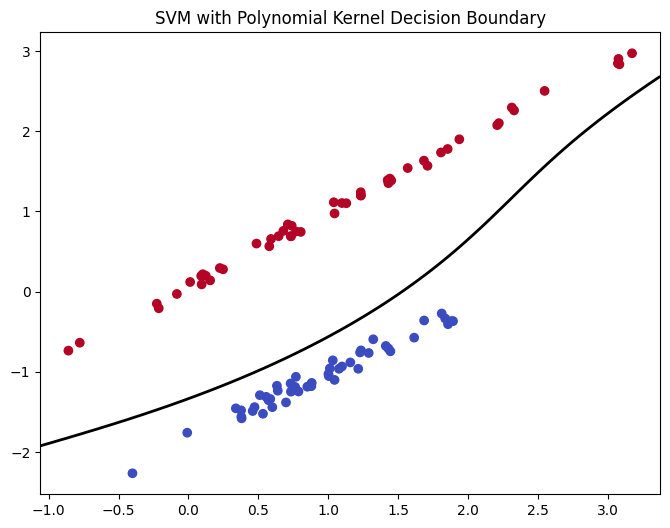

In [4]:
# Q24Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Generate synthetic dataset (2D for visualization)
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=100, random_state=42)

# Train SVM with polynomial kernel
poly_svm = SVC(kernel='poly', degree=3)
poly_svm.fit(X, y)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

# Create grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))

Z = poly_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
plt.title("SVM with Polynomial Kernel Decision Boundary")
plt.show()

In [5]:
# Q25: Write a Python program to train a Gaussian Naive Bayes classifier on the Breast Cancer dataset and evaluate accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Gaussian NB on Breast Cancer):", accuracy)

Accuracy (Gaussian NB on Breast Cancer): 0.9415204678362573


In [6]:
# Q26: Write a Python program to train a Multinomial Naive Bayes classifier for text classification using the 20 Newsgroups dataset.

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
newsgroups = fetch_20newsgroups(subset='all')
X, y = newsgroups.data, newsgroups.target

# Convert text to bag-of-words
vectorizer = CountVectorizer(stop_words='english')
X_vec = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Predictions
y_pred = mnb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Multinomial NB on 20 Newsgroups):", accuracy)

Accuracy (Multinomial NB on 20 Newsgroups): 0.8749557835160948


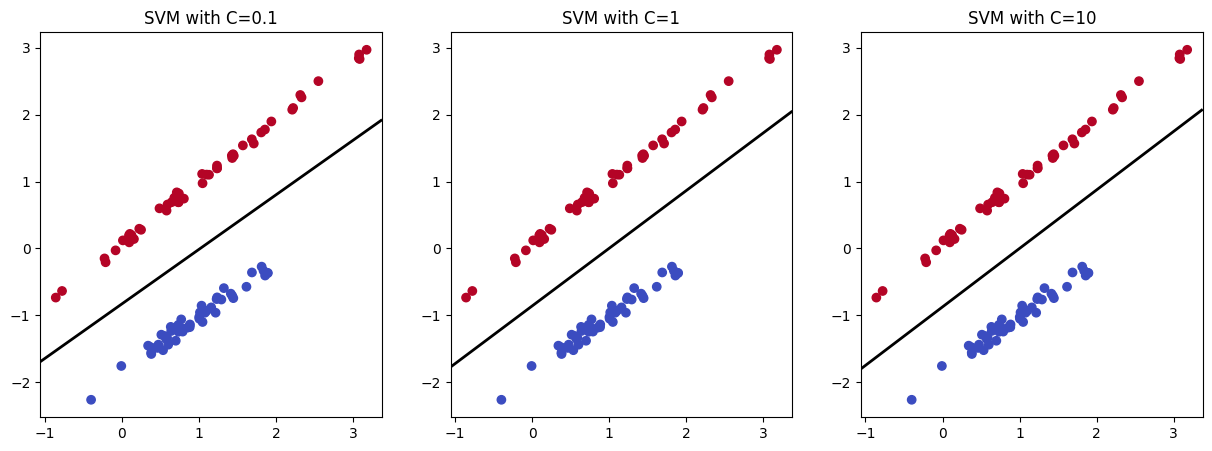

In [7]:
# Q27: Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Generate synthetic dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=100, random_state=42)

# Different C values
C_values = [0.1, 1, 10]

plt.figure(figsize=(15,5))

for i, C in enumerate(C_values, 1):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)
    
    # Plot decision boundary
    plt.subplot(1,3,i)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                         np.linspace(ylim[0], ylim[1], 100))
    
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.title(f"SVM with C={C}")

plt.show()

In [8]:
# Q28:Write a Python program to train a Bernoulli Naive Bayes classifier for binary classification on a dataset with binary features.

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# Generate binary dataset
X, y = make_classification(n_features=10, n_informative=5, n_redundant=0,
                           n_classes=2, random_state=42)

# Convert features to binary (0/1)
X_binary = (X > 0).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=0.3, random_state=42)

# Train Bernoulli Naive Bayes
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

# Predictions
y_pred = bnb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Bernoulli NB):", accuracy)

Accuracy (Bernoulli NB): 0.8666666666666667


In [9]:
# Q29:  Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without scaling
svm_unscaled = SVC(kernel='rbf')
svm_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_scaled = SVC(kernel='rbf')
svm_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, svm_scaled.predict(X_test))

print("Accuracy without scaling:", acc_unscaled)
print("Accuracy with scaling:", acc_scaled)

Accuracy without scaling: 0.7592592592592593
Accuracy with scaling: 0.3888888888888889


In [10]:
# Q30: Write a Python program to train a Gaussian Naive Bayes model and compare the predictions before and after Laplace Smoothing.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without Laplace smoothing
gnb = GaussianNB()
gnb.fit(X_train, y_train)
acc_no_smoothing = accuracy_score(y_test, gnb.predict(X_test))

# With Laplace smoothing (var_smoothing parameter)
gnb_smooth = GaussianNB(var_smoothing=1e-2)
gnb_smooth.fit(X_train, y_train)
acc_smoothing = accuracy_score(y_test, gnb_smooth.predict(X_test))

print("Accuracy without Laplace Smoothing:", acc_no_smoothing)
print("Accuracy with Laplace Smoothing:", acc_smoothing)

Accuracy without Laplace Smoothing: 0.9415204678362573
Accuracy with Laplace Smoothing: 0.935672514619883


In [11]:
# Q31: Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel).
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

# GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9276666666666668


In [12]:
# Q32: Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Generate imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2,
                           weights=[0.9, 0.1], random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without class weights
svm_no_weights = SVC(kernel='linear')
svm_no_weights.fit(X_train, y_train)
acc_no_weights = accuracy_score(y_test, svm_no_weights.predict(X_test))

# With class weights
svm_weights = SVC(kernel='linear', class_weight='balanced')
svm_weights.fit(X_train, y_train)
acc_weights = accuracy_score(y_test, svm_weights.predict(X_test))

print("Accuracy without class weights:", acc_no_weights)
print("Accuracy with class weights:", acc_weights)

Accuracy without class weights: 0.91
Accuracy with class weights: 0.8466666666666667


In [13]:
# Q33Write a Python program to implement a Naive Bayes classifier for spam detection using email data.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Example dataset (replace with actual spam dataset)
data = {
    'text': ["Win money now", "Hello friend", "Claim your prize", "Meeting at 5pm", "Free lottery ticket"],
    'label': [1, 0, 1, 0, 1]  # 1 = spam, 0 = not spam
}
df = pd.DataFrame(data)

# Features and labels
X, y = df['text'], df['label']

# Convert text to bag-of-words
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predictions
y_pred = nb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Spam Detection Accuracy:", accuracy)

Spam Detection Accuracy: 0.5


In [14]:
# 34 Write a Python program to train an SVM Classifier and a Naive Bayes Classifier on the same dataset and compare their accuracy

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))

# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))

print("SVM Accuracy:", svm_acc)
print("Naive Bayes Accuracy:", nb_acc)

SVM Accuracy: 0.9814814814814815
Naive Bayes Accuracy: 1.0


In [15]:
# Q35: Write a Python program to perform feature selection before training a Naive Bayes classifier and compare results

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without feature selection
nb = GaussianNB()
nb.fit(X_train, y_train)
acc_no_fs = accuracy_score(y_test, nb.predict(X_test))

# With feature selection (top 10 features)
selector = SelectKBest(chi2, k=10)
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

nb_fs = GaussianNB()
nb_fs.fit(X_train_fs, y_train)
acc_fs = accuracy_score(y_test, nb_fs.predict(X_test_fs))

print("Accuracy without feature selection:", acc_no_fs)
print("Accuracy with feature selection:", acc_fs)

Accuracy without feature selection: 0.9415204678362573
Accuracy with feature selection: 0.9532163742690059


In [16]:
# Q36:Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# One-vs-Rest
svm_ovr = SVC(kernel='linear', decision_function_shape='ovr')
svm_ovr.fit(X_train, y_train)
acc_ovr = accuracy_score(y_test, svm_ovr.predict(X_test))

# One-vs-One
svm_ovo = SVC(kernel='linear', decision_function_shape='ovo')
svm_ovo.fit(X_train, y_train)
acc_ovo = accuracy_score(y_test, svm_ovo.predict(X_test))

print("OvR Accuracy:", acc_ovr)
print("OvO Accuracy:", acc_ovo)

OvR Accuracy: 0.9814814814814815
OvO Accuracy: 0.9814814814814815


In [17]:
# Q37 Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear Kernel
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, linear_svm.predict(X_test))

# Polynomial Kernel
poly_svm = SVC(kernel='poly', degree=3)
poly_svm.fit(X_train, y_train)
acc_poly = accuracy_score(y_test, poly_svm.predict(X_test))

# RBF Kernel
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, rbf_svm.predict(X_test))

print("Linear Kernel Accuracy:", acc_linear)
print("Polynomial Kernel Accuracy:", acc_poly)
print("RBF Kernel Accuracy:", acc_rbf)

Linear Kernel Accuracy: 0.9649122807017544
Polynomial Kernel Accuracy: 0.9415204678362573
RBF Kernel Accuracy: 0.935672514619883


In [18]:
# Q38: Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy

from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVM model
svm_model = SVC(kernel='linear')

# Cross-validation
scores = cross_val_score(svm_model, X, y, cv=skf)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.94444444 1.         0.94444444 0.97142857 1.        ]
Average accuracy: 0.9720634920634922


In [19]:
# Q39: Write a Python program to train a Naive Bayes classifier using different prior probabilities and compare performance

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Default priors
gnb_default = GaussianNB()
gnb_default.fit(X_train, y_train)
acc_default = accuracy_score(y_test, gnb_default.predict(X_test))

# Custom priors (equal probability)
gnb_custom = GaussianNB(priors=[0.5, 0.5])
gnb_custom.fit(X_train, y_train)
acc_custom = accuracy_score(y_test, gnb_custom.predict(X_test))

print("Accuracy with default priors:", acc_default)
print("Accuracy with custom priors:", acc_custom)

Accuracy with default priors: 0.9415204678362573
Accuracy with custom priors: 0.9415204678362573


In [20]:
# Q40 Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Base SVM model
svm_model = SVC(kernel='linear')

# RFE (select top 10 features)
selector = RFE(svm_model, n_features_to_select=10)
selector.fit(X_train, y_train)

# Transform dataset
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

# Train SVM on reduced features
svm_rfe = SVC(kernel='linear')
svm_rfe.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, svm_rfe.predict(X_test_rfe))

print("Accuracy after RFE:", acc_rfe)

Accuracy after RFE: 0.9298245614035088


In [21]:
#41 Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.9636363636363636
Recall: 0.9814814814814815
F1-Score: 0.9724770642201835


In [22]:
#42 Write a Python program to train a Naive Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict probabilities
y_prob = nb_model.predict_proba(X_test)

# Log Loss
loss = log_loss(y_test, y_prob)
print("Log Loss (Naive Bayes):", loss)


Log Loss (Naive Bayes): 0.48986013210958873


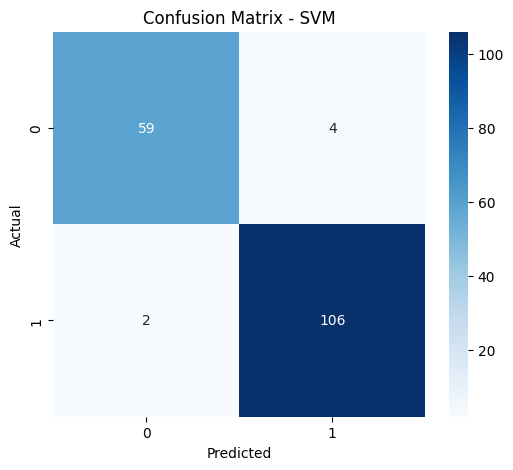

In [23]:
#43 Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
#44 Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing() # Load dataset
X, y = housing.data, housing.target

scaler = StandardScaler() # Scale features
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42) # Train-test split

svr_model = SVR(kernel='rbf') # Train SVR
svr_model.fit(X_train, y_train)

y_pred = svr_model.predict(X_test) # Predictions
mae = mean_absolute_error(y_test, y_pred) # MAE
print("Mean Absolute Error (SVR):", mae)


Mean Absolute Error (SVR): 0.3963460537586391


ROC-AUC Score (Naive Bayes): 0.9922104644326867


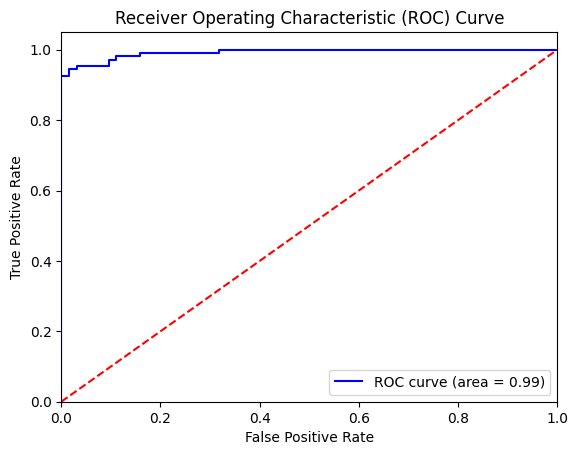

In [25]:
#45 Write a Python program to train a Naive Bayes classifier and evaluate its performance using the ROC-AUC score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score


cancer = load_breast_cancer() # Load dataset
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Train-test split

nb_model = GaussianNB()   # Train Naive Bayes
nb_model.fit(X_train, y_train)

y_prob = nb_model.predict_proba(X_test)[:,1]  # Predict probabilities

roc_auc = roc_auc_score(y_test, y_prob)    # ROC-AUC
print("ROC-AUC Score (Naive Bayes):", roc_auc)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()  

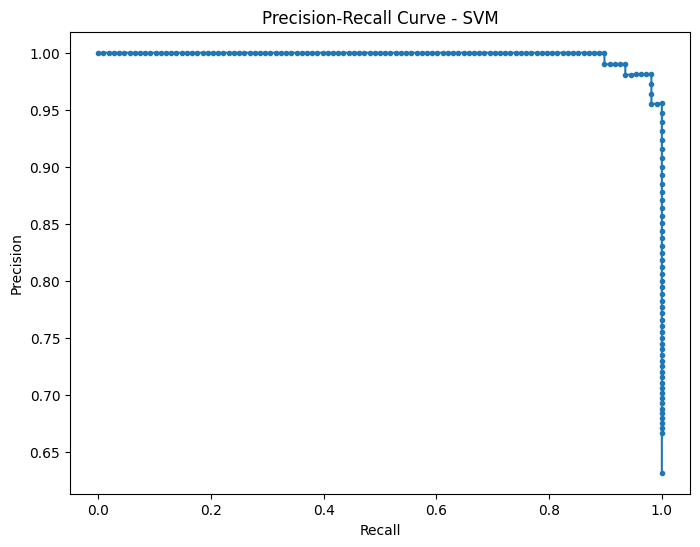

In [26]:
#46 Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM with probability estimates
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Predict probabilities
y_scores = svm_model.predict_proba(X_test)[:,1]

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve - SVM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()